# Кластеризация и классификация фильмов на основе текстовых описаний

**Цель работы:** Провести сравнительный анализ различных алгоритмов кластеризации и обучить модель классификации, следуя методологии из работы по анализу данных пингвинов.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Загрузка и подготовка данных

In [35]:
df = pd.read_csv('processed_films.csv')
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['text_lemm'].fillna('')).toarray()

## 2. Сравнение моделей кластеризации

Используем три алгоритма: K-Means, DBSCAN и Agglomerative Clustering.

### 2.1 K-Means и метод локтя

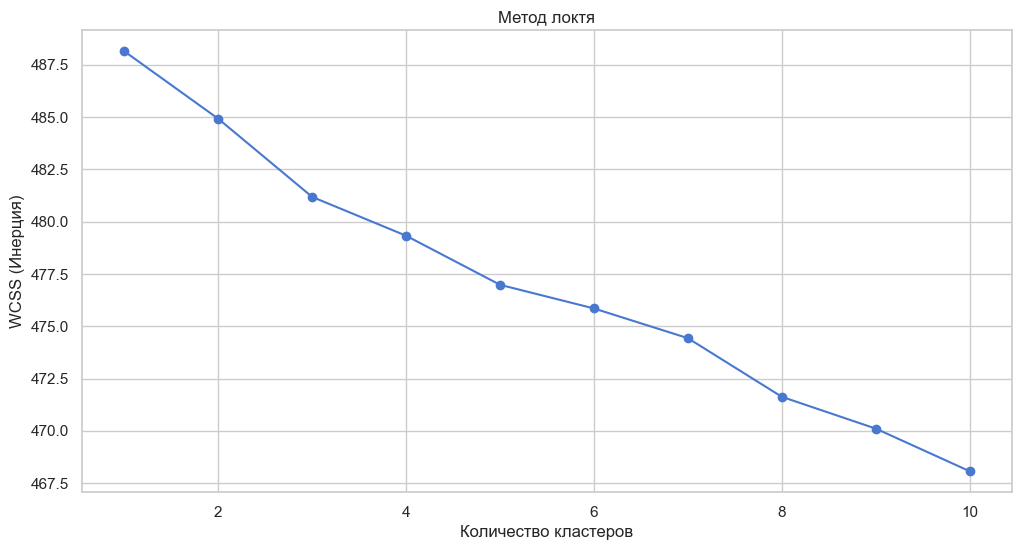

In [ ]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS (Инерция)')
plt.show()

In [37]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X)

sil_km = silhouette_score(X, df['kmeans_cluster'])
dav_km = davies_bouldin_score(X, df['kmeans_cluster'])
print(f"K-Means: Silhouette={sil_km:.3f}, Davies-Bouldin={dav_km:.3f}")

K-Means: Silhouette=0.006, Davies-Bouldin=9.613


### 2.2 DBSCAN

In [38]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X)

unique_labels = set(df['dbscan_cluster'])
if len(unique_labels) > 1:
    sil_db = silhouette_score(X, df['dbscan_cluster'])
    dav_db = davies_bouldin_score(X, df['dbscan_cluster'])
else:
    sil_db, dav_db = 0, 0

print(f"DBSCAN: Количество кластеров (вкл. шум): {len(unique_labels)}")

DBSCAN: Количество кластеров (вкл. шум): 1


### 2.3 Agglomerative Clustering

In [39]:
agg = AgglomerativeClustering(n_clusters=5)
df['agg_cluster'] = agg.fit_predict(X)

sil_agg = silhouette_score(X, df['agg_cluster'])
dav_agg = davies_bouldin_score(X, df['agg_cluster'])
print(f"Agglomerative: Silhouette={sil_agg:.3f}, Davies-Bouldin={dav_agg:.3f}")

Agglomerative: Silhouette=0.004, Davies-Bouldin=4.490


## 3. Визуализация и выбор лучшей модели

Используем t-SNE для визуализации распределения кластеров каждой модели.

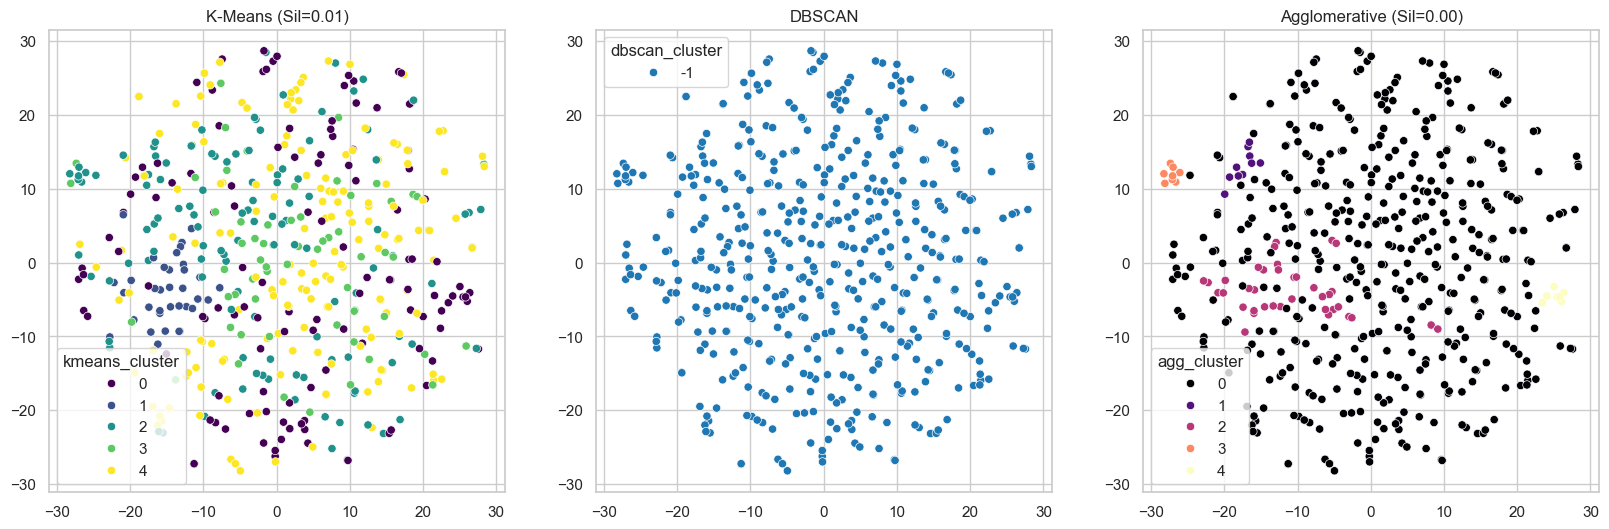

In [40]:
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['kmeans_cluster'], palette='viridis', ax=axes[0])
axes[0].set_title(f'K-Means (Sil={sil_km:.2f})')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['dbscan_cluster'], palette='tab10', ax=axes[1])
axes[1].set_title('DBSCAN')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['agg_cluster'], palette='magma', ax=axes[2])
axes[2].set_title(f'Agglomerative (Sil={sil_agg:.2f})')

plt.show()

## 4. Классификация

Как и в примере, обучим классификатор Random Forest для предсказания высокой оценки.

Результаты классификации:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        92
           1       0.00      0.00      0.00         8

    accuracy                           0.92       100
   macro avg       0.46      0.50      0.48       100
weighted avg       0.85      0.92      0.88       100



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


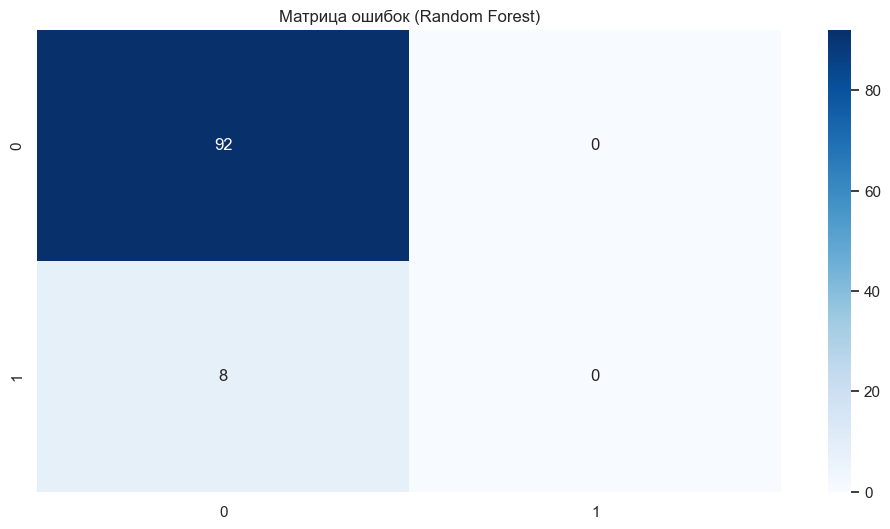

In [41]:
df['high_rating'] = (df['rating'] > 8.5).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, df['high_rating'], test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Результаты классификации:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Random Forest)')
plt.show()